# Configuración básica (no tocar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [2]:
x = Variable()

# Implementación de métodos

In [ ]:
# Implementar para hallar raíces de las derivadas, no de f.
# agarra un intervalo y lo va achicando hasta encontrar donde la derivada se hace cero.
# también contempla el caso donde justo la derivada vale cero en un extremo.
def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()

    fa = df.eval(a)
    fb = df.eval(b)

    if abs(fa) < tol:
        return a, 0

    if abs(fb) < tol:
        return b, 0

    if fa * fb > 0:
        return None, 0

    for step in range(1, max_iter + 1):
        m = (a + b) / 2
        fm = df.eval(m)

        if abs(fm) < tol or abs(b - a) < tol:
            return m, step

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return None, max_iter


# arranca en un punto y va corrigiendo usando la derivada y la segunda derivada.
def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()

    x_actual = x0

    for step in range(1, max_iter + 1):
        primera = df.eval(x_actual)
        segunda = ddf.eval(x_actual)

        if abs(primera) < tol:
            print("Newton convergió: la primera derivada es cercana a cero.")
            return x_actual, step

        if abs(segunda) < 1e-12:
            print("Newton se detuvo: la segunda derivada es cercana a cero.")
            return None, step

        x_siguiente = x_actual - primera / segunda

        if abs(x_siguiente - x_actual) < tol:
            print("Newton convergió: el cambio entre aproximaciones es menor que la tolerancia.")
            return x_siguiente, step

        x_actual = x_siguiente

    print("Newton no convergió: se alcanzó el máximo de iteraciones.")
    return None, max_iter

# va caminando cuesta abajo según la pendiente.
def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()

    x_actual = x0

    for step in range(1, max_iter + 1):
        gradiente = df.eval(x_actual)

        if abs(gradiente) < tol:
            print("Descenso por gradiente convergió: la derivada es cercana a cero.")
            return x_actual, step

        x_siguiente = x_actual - lr * gradiente

        if abs(x_siguiente - x_actual) < tol:
            print("Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.")
            return x_siguiente, step

        x_actual = x_siguiente

    print("Descenso por gradiente no convergió: se alcanzó el máximo de iteraciones.")
    return None, max_iter


### Prueba de métodos

Newton no convergió: se alcanzó el máximo de iteraciones.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Newton no convergió: se alcanzó el máximo de iteraciones.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Newton no convergió: se alcanzó el máximo de iteraciones.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.


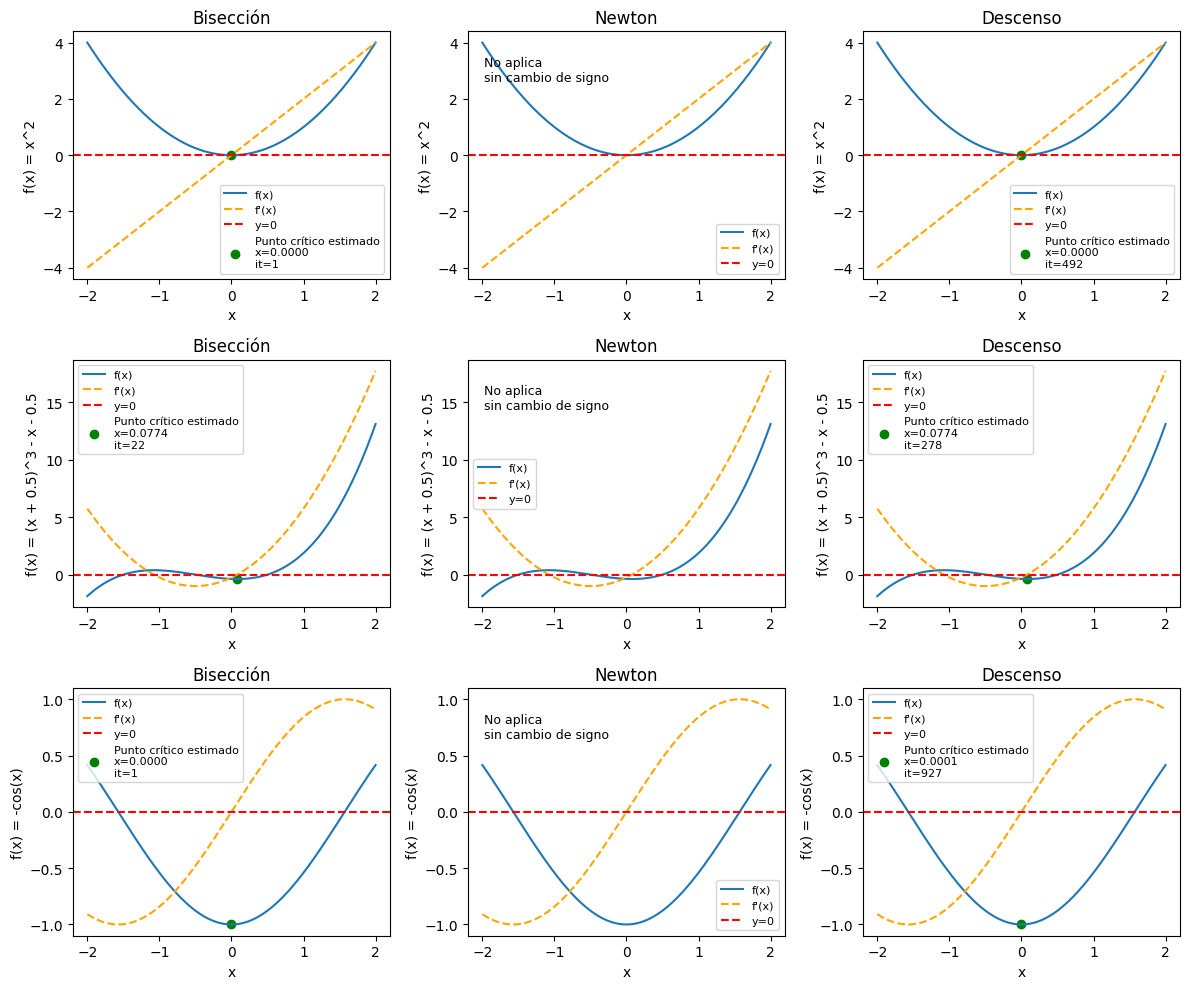

In [4]:
# Si bisección devuelve None, el intervalo elegido no presentaun cambio de signo de la derivada en sus extremos.
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]

# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [
    {"a": -1, "b": 1},
    {"x0": 1},
    {"x0": 1, "lr": 1e-2}
]

y_labels = [
    "f(x) = x^2",
    "f(x) = (x + 0.5)^3 - x - 0.5",
    "f(x) = -cos(x)"
]

titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, method in enumerate(methods):
        ax = axes[i, j]

        ax.set_xlabel("x")   
        ax.set_ylabel(y_labels[i])

        params = parameters[j]
        res, step = method(f, **params)

        valores_f = np.array([f.eval(v) for v in lp])
        valores_df = np.array([f.derivative().eval(v) for v in lp])

        ax.plot(lp, valores_f, label="f(x)")
        ax.plot(lp, valores_df, linestyle="--", color="orange", label="f'(x)")
        ax.axhline(0, linestyle="--", color="red", label="y=0")

        if res is not None:
            ax.scatter(res, f.eval(res), color="green", label=f"Punto crítico estimado\nx={res:.4f}\nit={step}")
        else:
            ax.text(
                0.05, 0.9,
                "No aplica\nsin cambio de signo",
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top"
            )

        ax.set_title(titles[j])
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [5]:
f = x**2 + 2*sin(3*x)

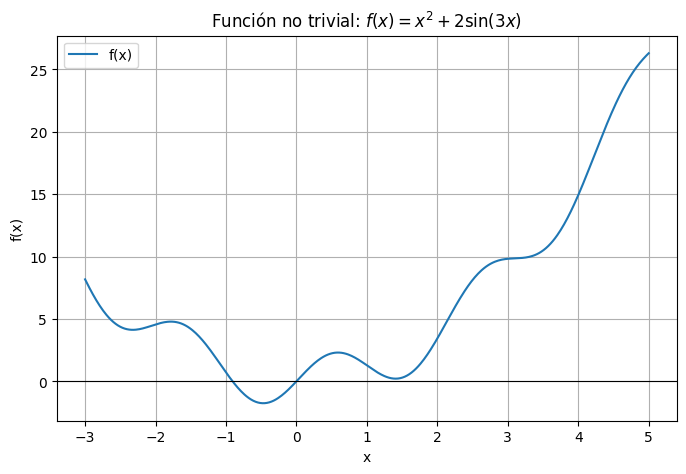

In [6]:
# Grafica de la función
lp = np.linspace(-3, 5, 500)

plt.figure(figsize=(8, 5))
plt.plot(lp, [f.eval(v) for v in lp], label="f(x)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Función no trivial: $f(x)=x^2+2\sin(3x)$")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Evaluación de métodos y generación de tablas
intervalos_biseccion = [(-2, 1), (-1, 0), (1, 2)]
puntos_newton = [-2, -1, 4]
puntos_gradiente = [-3, 0.585, 4]
lr = 0.01

# Predicciones realizadas antes de ejecutar los métodos
predicciones_biseccion = [
    "Encontrará un punto crítico dentro del intervalo",
    "Encontrará el mínimo local de la zona central",
    "Encontrará el mínimo local de la zona derecha"
]

predicciones_newton = [
    "Se acercará al punto crítico de la izquierda",
    "Se acercará a un punto crítico cercano al origen",
    "Puede alejarse o no converger"
]

predicciones_gradiente = [
    "Descenderá hacia el mínimo local de la izquierda",
    "Descenderá hacia el mínimo local central",
    "Descenderá hacia el mínimo local de la derecha"
]

# armo tabla para el informe
resultados = []

for (a, b), prediccion in zip(intervalos_biseccion, predicciones_biseccion):
    res, it = biseccion(f, a, b)
    resultados.append({
        "Método": "Bisección",
        "Condición inicial": f"[{a}, {b}]",
        "Predicción": prediccion,
        "Learning rate": "-",
        "Resultado": res,
        "f(x)": f.eval(res) if res is not None else None,
        "Iteraciones": it
    })

# Newton

for x0, prediccion in zip(puntos_newton, predicciones_newton):
    res, it = newton(f, x0)
    resultados.append({
        "Método": "Newton",
        "Condición inicial": x0,
        "Predicción": prediccion,
        "Learning rate": "-",
        "Resultado": res,
        "f(x)": f.eval(res) if res is not None else None,
        "Iteraciones": it

    })

# Descenso por gradiente
for x0, prediccion in zip(puntos_gradiente, predicciones_gradiente):
    res, it = descenso_gradiente(f, x0, lr)
    resultados.append({
        "Método": "Descenso por gradiente",
        "Condición inicial": x0,
        "Predicción": prediccion,
        "Learning rate": lr,
        "Resultado": res,
        "f(x)": f.eval(res) if res is not None else None,
        "Iteraciones": it
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

Newton no convergió: se alcanzó el máximo de iteraciones.
Newton no convergió: se alcanzó el máximo de iteraciones.
Newton no convergió: se alcanzó el máximo de iteraciones.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.


,Método,Condición inicial,Predicción,Learning rate,Resultado,f(x),Iteraciones
0,Bisección,"[-2, 1]",Encontrará un punto crítico dentro del intervalo,-,-1.782932,4.787319,23
1,Bisección,"[-1, 0]",Encontrará el mínimo local de la zona central,-,-0.471043,-1.753311,21
2,Bisección,"[1, 2]",Encontrará el mínimo local de la zona derecha,-,1.407957,0.216284,21
3,Newton,-2,Se acercará al punto crítico de la izquierda,-,NaN,NaN,1000
4,Newton,-1,Se acercará a un punto crítico cercano al origen,-,NaN,NaN,1000
5,Newton,4,Puede alejarse o no converger,-,NaN,NaN,1000
6,Descenso por gradiente,-3,Descenderá hacia el mínimo local de la izquierda,0.01,-2.322813,4.129721,77
7,Descenso por gradiente,0.585,Descenderá hacia el mínimo local central,0.01,-0.471039,-1.753311,89
8,Descenso por gradiente,4,Descenderá hacia el mínimo local de la derecha,0.01,1.407961,0.216284,180


### Comparación de learning rates

In [8]:
# aregamos esta celda en el notebook para la prueba descenso por gradiente con varios learning rates.
# sirve para discutir si el método tarda mucho, oscila o converge mejor.

learning_rates = [0.001, 0.01, 0.05, 0.1]
puntos_gradiente = [-3, 0.585, 4]

resultados_lr = []

for x0 in puntos_gradiente:
    for lr in learning_rates:
        res, it = descenso_gradiente(f, x0, lr)
        resultados_lr.append({
            "Punto inicial": x0,
            "Learning rate": lr,
            "Resultado": res,
            "f(x)": f.eval(res) if res is not None else None,
            "Iteraciones": it
        })

df_lr = pd.DataFrame(resultados_lr)
df_lr

Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente no convergió: se alcanzó el máximo de iteraciones.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la tolerancia.
Descenso por gradiente convergió: el cambio entre aproximaciones es menor que la toleranc

,Punto inicial,Learning rate,Resultado,f(x),Iteraciones
0,-3.000,0.001,-2.322881,4.129721,636
1,-3.000,0.010,-2.322813,4.129721,77
2,-3.000,0.050,-2.322808,4.129721,12
3,-3.000,0.100,-2.322807,4.129721,16
4,0.585,0.001,-0.470994,-1.753311,795
5,0.585,0.010,-0.471039,-1.753311,89
6,0.585,0.050,-0.471043,-1.753311,14
7,0.585,0.100,-0.471043,-1.753311,511
8,4.000,0.001,NaN,NaN,1000
9,4.000,0.010,1.407961,0.216284,180


### Evolución de las aproximaciones

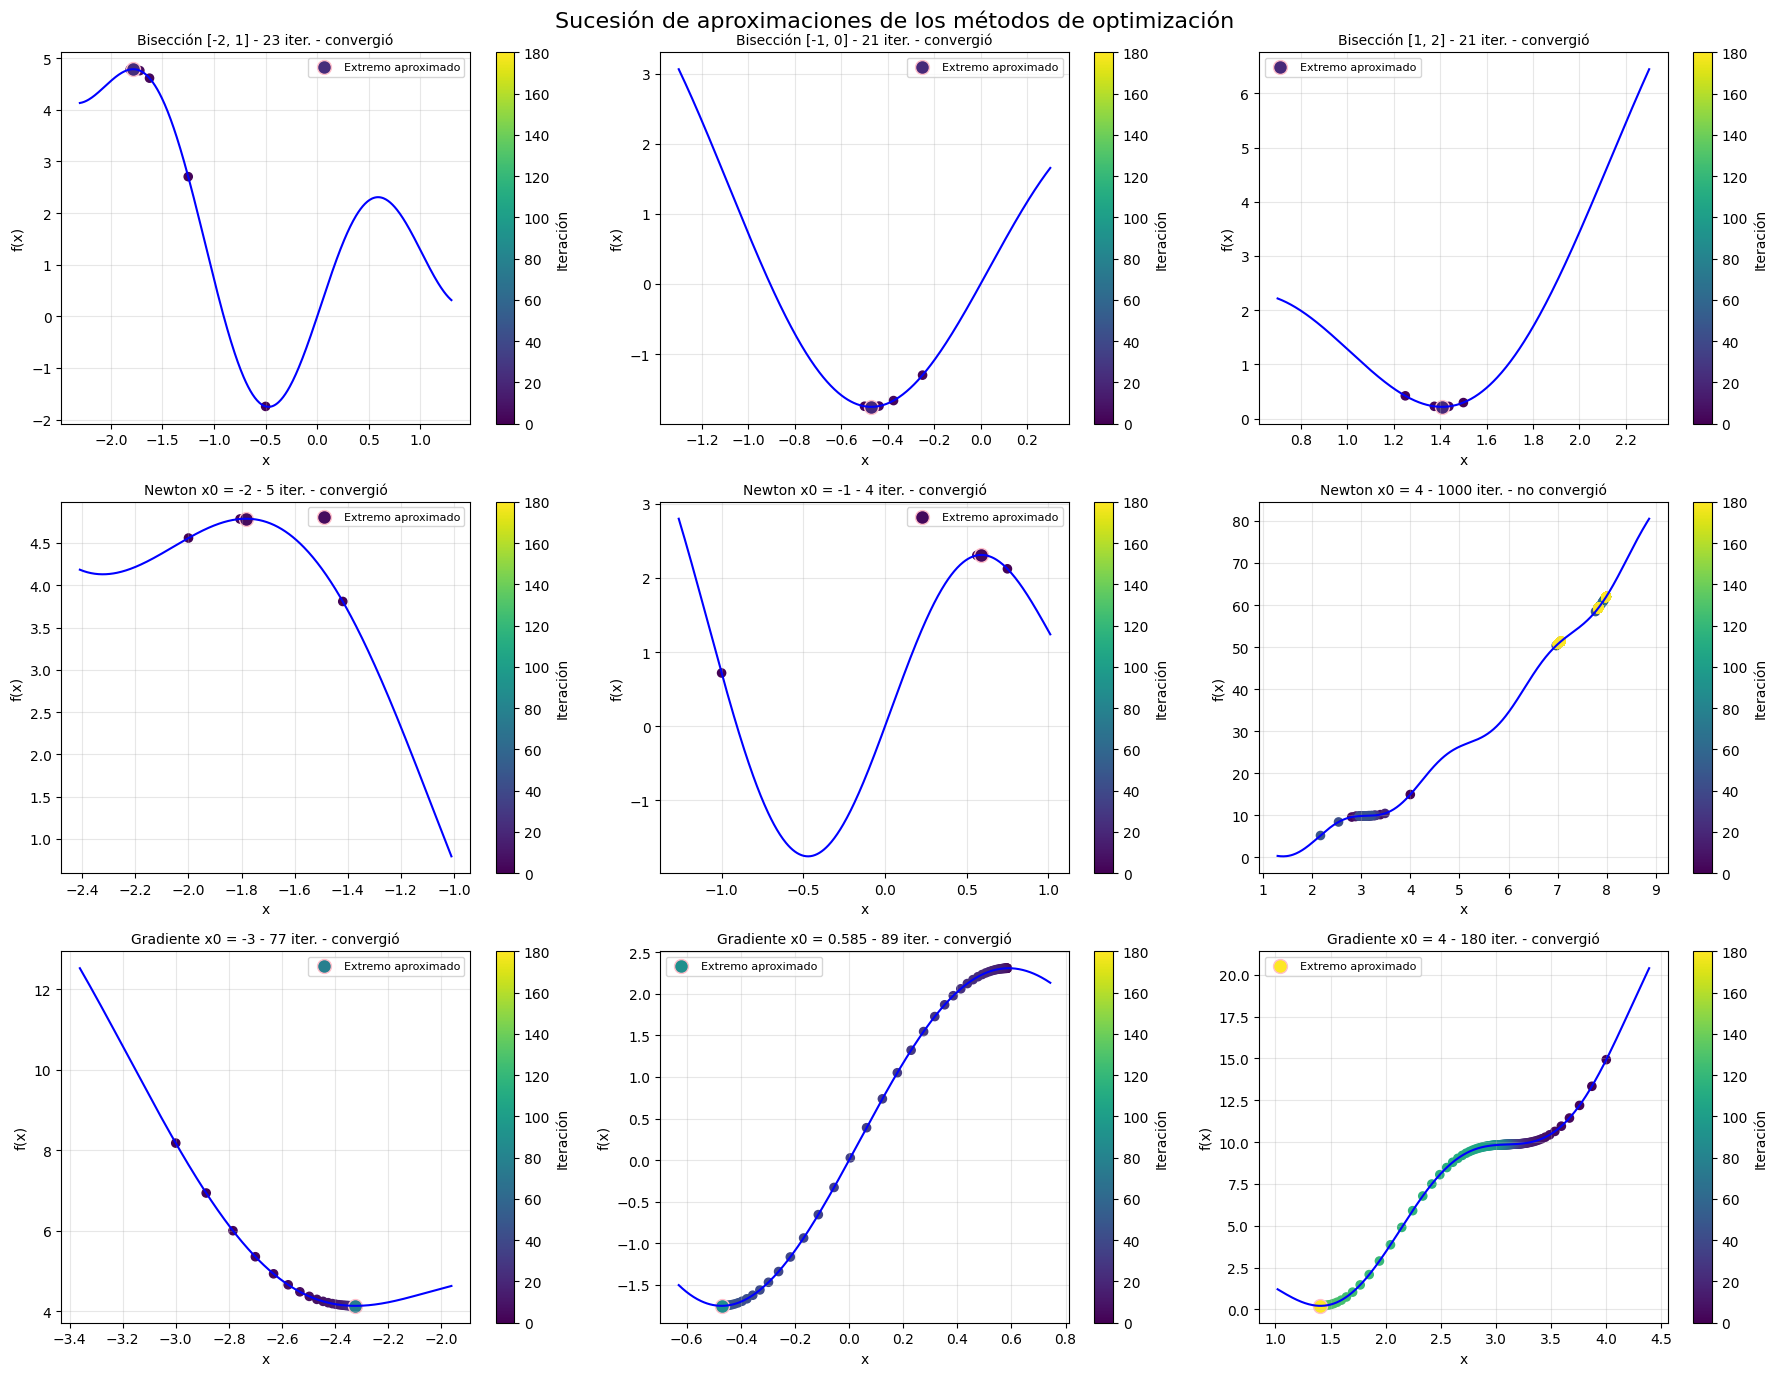

In [ ]:
# gráficas

# Primero ejecutamos todos los métodos y guardamos los resultados
resultados = []

for metodo, condicion, ejecutar in experimentos:
    resultado, iteraciones, historial, convergio = ejecutar()
    resultados.append((metodo, condicion, resultado, iteraciones, historial, convergio))

# Usamos una escala común de colores para todos los métodos que convergen.
# Así el color representa el número real de iteración, no "el último punto de cada gráfica".
max_iter_color = max(
    iteraciones for _, _, _, iteraciones, _, convergio in resultados if convergio
)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=0, vmax=max_iter_color)

for i, (metodo, condicion, resultado, iteraciones, historial, convergio) in enumerate(resultados):
    ax = axes[i]

    historial = np.array(historial)
    valores = np.array([f.eval(x) for x in historial])

    # Para Newton y gradiente, el primer punto es x0, o sea iteración 0.
    # Para bisección, el primer punto graficado es el primer punto medio, o sea iteración 1.
    if metodo == "Bisección":
        colores = np.arange(1, len(historial) + 1)
    else:
        colores = np.arange(len(historial))

    # Rango de x para mostrar bien cada caso
    x_min = np.min(historial)
    x_max = np.max(historial)

    if x_max - x_min < 1:
        centro = (x_min + x_max) / 2
        x_min = centro - 0.7
        x_max = centro + 0.7
    else:
        margen = 0.15 * (x_max - x_min)
        x_min -= margen
        x_max += margen

    # Para bisección se muestra el intervalo inicial completo
    if metodo == "Bisección":
        if condicion == "[-2, 1]":
            x_min, x_max = -2.3, 1.3
        elif condicion == "[-1, 0]":
            x_min, x_max = -1.3, 0.3
        elif condicion == "[1, 2]":
            x_min, x_max = 0.7, 2.3

    x_plot = np.linspace(x_min, x_max, 500)
    y_plot = [f.eval(x) for x in x_plot]

    # Función
    ax.plot(x_plot, y_plot, color="blue")

    # Sucesión de aproximaciones coloreada por número real de iteración
    puntos = ax.scatter(
        historial,
        valores,
        c=colores,
        cmap=cmap,
        norm=norm,
        s=35
    )

    # Si converge, marcamos el extremo aproximado con un rombo
    # del color correspondiente a la iteración en la que se alcanzó.
    if convergio:
        color_final = cmap(norm(iteraciones))

        ax.scatter(
            historial[-1],
            valores[-1],
            color=color_final,
            marker="o",
            s=100,
            edgecolors="red",
            linewidths=1,
            label="Extremo aproximado"
        )

    estado = "convergió" if convergio else "no convergió"

    ax.set_title(
        f"{metodo} {condicion} - {iteraciones} iter. - {estado}",
        fontsize=10
    )

    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)

    if convergio:
        ax.legend(fontsize=8)

    cbar = plt.colorbar(puntos, ax=ax)
    cbar.set_label("Iteración")


plt.suptitle(
    "Sucesión de aproximaciones de los métodos de optimización",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Ajuste de datos

In [ ]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

df_linear.head(), df_exp.head(), df_sin.head() # para confirmar como se llaman las columnas (onda x e y)

In [ ]:
# Genere la función de pérdida
def obtener_xy(df):
    xs = df.iloc[:, 0].to_numpy()
    ys = df.iloc[:, 1].to_numpy()
    return xs, ys

# para el modelo lineal
def perdida_lineal(df):
    xs, ys = obtener_xy(df)

    total = 0
    for xi, yi in zip(xs, ys):
        pred = w * xi
        total += (pred - yi)**2

    return total / len(xs)

# para el exponencial
def perdida_exp(df):
    xs, ys = obtener_xy(df)

    total = 0
    for xi, yi in zip(xs, ys):
        pred = exp(w * xi)
        total += (pred - yi)**2

    return total / len(xs)

# para el senoidal
def perdida_senoidal(df):
    xs, ys = obtener_xy(df)

    total = 0
    for xi, yi in zip(xs, ys):
        pred = sin(w * xi)
        total += (pred - yi)**2

    return total / len(xs)


L_linear = perdida_lineal(df_linear)
L_exp = perdida_exp(df_exp)
L_sin = perdida_senoidal(df_sin)

L_linear, L_exp, L_sin

### Gráfica de las funciones de pérdida

In [ ]:
# Gráficas individuales de las funciones de pérdida

valores_w_linear = np.linspace(-1, 5, 500)
valores_w_exp = np.linspace(-0.2, 0.7, 500)
valores_w_sin = np.linspace(-3, 3, 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Modelo lineal
axes[0].plot(
    valores_w_linear,
    [L_linear.eval(v) for v in valores_w_linear]
)
axes[0].set_xlabel("w")
axes[0].set_ylabel("L(w)")
axes[0].set_title("Pérdida del modelo lineal")
axes[0].grid(True)

# Modelo exponencial
axes[1].plot(
    valores_w_exp,
    [L_exp.eval(v) for v in valores_w_exp]
)
axes[1].set_xlabel("w")
axes[1].set_ylabel("L(w)")
axes[1].set_title("Pérdida del modelo exponencial")
axes[1].grid(True)

# Modelo senoidal
axes[2].plot(
    valores_w_sin,
    [L_sin.eval(v) for v in valores_w_sin]
)
axes[2].set_xlabel("w")
axes[2].set_ylabel("L(w)")
axes[2].set_title("Pérdida del modelo senoidal")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Optimice la función de pérdida
res_lin, it_lin = descenso_gradiente(L_linear, x0=0, lr=0.01)
res_exp, it_exp = descenso_gradiente(L_exp, x0=0, lr=0.001)
res_sin, it_sin = descenso_gradiente(L_sin, x0=1, lr=0.01)

tabla_ajuste = pd.DataFrame([
    {
        "Modelo": "Lineal",
        "Condición inicial": 0,
        "Learning rate": 0.01,
        "w obtenido": res_lin,
        "Pérdida final": (
            L_linear.eval(res_lin)
            if res_lin is not None
            else None
        ),
        "Iteraciones": it_lin
    },
    {
        "Modelo": "Exponencial",
        "Condición inicial": 0,
        "Learning rate": 0.001,
        "w obtenido": res_exp,
        "Pérdida final": (
            L_exp.eval(res_exp)
            if res_exp is not None
            else None
        ),
        "Iteraciones": it_exp
    },
    {
        "Modelo": "Senoidal",
        "Condición inicial": 1,
        "Learning rate": 0.01,
        "w obtenido": res_sin,
        "Pérdida final": (
            L_sin.eval(res_sin)
            if res_sin is not None
            else None
        ),
        "Iteraciones": it_sin
    }
])

tabla_ajuste

In [ ]:
def graficar_ajuste(df, modelo, w_opt, titulo):
    if w_opt is None:
        print(f"No se puede graficar {titulo}: el método no convergió.")
        return

    xs_datos, ys_datos = obtener_xy(df)

    xs = np.linspace(xs_datos.min(), xs_datos.max(), 500)

    if modelo == "lineal":
        ys = w_opt * xs
    elif modelo == "exp":
        ys = np.exp(w_opt * xs)
    elif modelo == "sin":
        ys = np.sin(w_opt * xs)
    else:
        raise ValueError("Modelo no reconocido")

    plt.figure(figsize=(8, 5))
    plt.scatter(xs_datos, ys_datos, label="Datos")
    plt.plot(xs, ys, label="Modelo ajustado")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()


graficar_ajuste(df_linear, "lineal", res_lin, "Ajuste del modelo lineal")
graficar_ajuste(df_exp, "exp", res_exp, "Ajuste del modelo exponencial")
graficar_ajuste(df_sin, "sin", res_sin, "Ajuste del modelo senoidal")

# BONUS:

## Bonus 1: Descenso por gradiente estocástico

In [ ]:
# implementa SGD y compara contra descenso por gradiente normal.
def sgd_lineal(df, w0, lr, max_iter=1000):
    xs, ys = obtener_xy(df)

    w_actual = w0
    historial = []

    for step in range(1, max_iter + 1):
        i = np.random.randint(0, len(xs))

        xi = xs[i]
        yi = ys[i]

        grad = 2 * (w_actual * xi - yi) * xi

        w_actual = w_actual - lr * grad
        historial.append(w_actual)

    return w_actual, max_iter, historial


def sgd_exp(df, w0, lr, max_iter=1000):
    xs, ys = obtener_xy(df)

    w_actual = w0
    historial = []

    for step in range(1, max_iter + 1):
        i = np.random.randint(0, len(xs))

        xi = xs[i]
        yi = ys[i]

        pred = np.exp(w_actual * xi)
        grad = 2 * (pred - yi) * pred * xi

        w_actual = w_actual - lr * grad

        if not np.isfinite(w_actual):
            print("SGD exponencial se detuvo por desbordamiento numérico.")
            return None, step, historial

        historial.append(w_actual)

    return w_actual, max_iter, historial


def sgd_sin(df, w0, lr, max_iter=1000):
    xs, ys = obtener_xy(df)

    w_actual = w0
    historial = []

    for step in range(1, max_iter + 1):
        i = np.random.randint(0, len(xs))

        xi = xs[i]
        yi = ys[i]

        pred = np.sin(w_actual * xi)
        grad = 2 * (pred - yi) * np.cos(w_actual * xi) * xi

        w_actual = w_actual - lr * grad
        historial.append(w_actual)

    return w_actual, max_iter, historial


w_sgd_lin, it_sgd_lin, hist_sgd_lin = sgd_lineal(df_linear, w0=0, lr=0.01, max_iter=1000)
w_sgd_exp, it_sgd_exp, hist_sgd_exp = sgd_exp(df_exp, w0=0, lr=0.001, max_iter=1000)
w_sgd_sin, it_sgd_sin, hist_sgd_sin = sgd_sin(df_sin, w0=1, lr=0.01, max_iter=1000)

tabla_sgd = pd.DataFrame([
    {
        "Modelo": "Lineal",
        "Método": "GD",
        "w obtenido": res_lin,
        "Pérdida final": L_linear.eval(res_lin),
        "Iteraciones": it_lin
    },
    {
        "Modelo": "Lineal",
        "Método": "SGD",
        "w obtenido": w_sgd_lin,
        "Pérdida final": L_linear.eval(w_sgd_lin),
        "Iteraciones": it_sgd_lin
    },
    {
        "Modelo": "Exponencial",
        "Método": "GD",
        "w obtenido": res_exp,
        "Pérdida final": L_exp.eval(res_exp),
        "Iteraciones": it_exp
    },
    {
        "Modelo": "Exponencial",
        "Método": "SGD",
        "w obtenido": w_sgd_exp,
        "Pérdida final": (
            L_exp.eval(w_sgd_exp)
            if w_sgd_exp is not None
            else None
        ),
        "Iteraciones": it_sgd_exp
    },
    {
        "Modelo": "Senoidal",
        "Método": "GD",
        "w obtenido": res_sin,
        "Pérdida final": L_sin.eval(res_sin),
        "Iteraciones": it_sin
    },
    {
        "Modelo": "Senoidal",
        "Método": "SGD",
        "w obtenido": w_sgd_sin,
        "Pérdida final": L_sin.eval(w_sgd_sin),
        "Iteraciones": it_sgd_sin
    }
])

tabla_sgd

### Evolución de SGD

In [ ]:
# Evolución de SGD para cada modelo
# La línea horizontal muestra el valor obtenido con GD estándar.

def graficar_evolucion_sgd(historial, w_gd, titulo):
    plt.figure(figsize=(8, 4))

    plt.plot(
        historial,
        linewidth=1,
        alpha=0.8,
        label="SGD"
    )

    plt.axhline(
        w_gd,
        linestyle="--",
        color="red",
        linewidth=2,
        label=f"GD estándar: w = {w_gd:.4f}"
    )

    plt.xlabel("Iteración")
    plt.ylabel("w")
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


graficar_evolucion_sgd(
    hist_sgd_lin,
    res_lin,
    "Evolución de SGD en el modelo lineal"
)

graficar_evolucion_sgd(
    hist_sgd_exp,
    res_exp,
    "Evolución de SGD en el modelo exponencial"
)

graficar_evolucion_sgd(
    hist_sgd_sin,
    res_sin,
    "Evolución de SGD en el modelo senoidal"
)

## Bonus 2: Descenso por gradiente con learning rate variable

In [ ]:
# compara descenso por gradiente con learning rate fijo contra learning rate variable.
def descenso_gradiente_lr_variable(f: Function, x0: float, lr0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()

    x_actual = x0
    historial = [x_actual]

    for step in range(1, max_iter + 1):
        lr_k = lr0 / step
        gradiente = df.eval(x_actual)

        if abs(gradiente) < tol:
            return x_actual, step, historial

        x_siguiente = x_actual - lr_k * gradiente
        historial.append(x_siguiente)

        if abs(x_siguiente - x_actual) < tol:
            return x_siguiente, step, historial

        x_actual = x_siguiente

    return x_actual, max_iter, historial


resultados_lr_variable = []

for x0 in [-3, 0.585, 4]:
    res_fijo, it_fijo = descenso_gradiente(f, x0, 0.01)
    res_var, it_var, hist_var = descenso_gradiente_lr_variable(f, x0, 0.1)

    resultados_lr_variable.append({
        "Punto inicial": x0,
        "Tipo": "Fijo",
        "Resultado": res_fijo,
        "f(x)": f.eval(res_fijo) if res_fijo is not None else None,
        "Iteraciones": it_fijo
    })

    resultados_lr_variable.append({
        "Punto inicial": x0,
        "Tipo": "Variable",
        "Resultado": res_var,
        "f(x)": f.eval(res_var) if res_var is not None else None,
        "Iteraciones": it_var
    })

df_lr_variable = pd.DataFrame(resultados_lr_variable)
df_lr_variable

## Bonus 3: Productoria de exponenciales

In [ ]:
# compara la pérdida cuadrática contra la formulación de productoria.
# en realidad optimizamos una versión estable usando logaritmos/equivalencia, porque la productoria directa puede dar números demasiado chicos.
def productoria_exp(df, w_val):
    xs, ys = obtener_xy(df)

    producto = 1

    for xi, yi in zip(xs, ys):
        producto *= np.exp(-((w_val * xi - yi)**2))

    return producto


def perdida_lineal_suma(df):
    xs, ys = obtener_xy(df)

    total = 0
    for xi, yi in zip(xs, ys):
        pred = w * xi
        total += (pred - yi)**2

    return total


L_lineal_suma = perdida_lineal_suma(df_linear)

w_prod, it_prod = descenso_gradiente(L_lineal_suma, x0=0, lr=0.0001)

comparacion_prod = pd.DataFrame([
    {
        "Función objetivo": "Pérdida cuadrática promedio",
        "w obtenido": res_lin,
        "Iteraciones": it_lin,
        "Valor productoria": productoria_exp(df_linear, res_lin)
    },
    {
        "Función objetivo": "Suma cuadrática equivalente",
        "w obtenido": w_prod,
        "Iteraciones": it_prod,
        "Valor productoria": (productoria_exp(df_linear, w_prod)
            if w_prod is not None
            else None
        )
    }
])

comparacion_prod